# 25. 대상별 재탐색 보조 결과

MusicGen·Udio를 각각 Train·Validation에서 제외하고 LR·SVM·MERT의 후보를 대상별로 다시 비교한 저장 결과다. **172후보 재탐색**은 선택 절차가 달라 [26번 고정 설정 전이](26_unseen_fixed_classical_mert.ipynb)와 합치지 않는다. 원래 split과 10초 경계는 유지했다.

In [1]:
# 완료된 과거 대상별 재탐색 결과를 보조 분석으로만 읽고 run ID를 확인한다.
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert (
    ROOT / "docs/ROBUSTNESS_PROTOCOL.md"
).exists(), "프로젝트 루트에서 노트북을 실행하세요."
RUN_ID = "unseen_classical_mert_20260919T171142Z"
RESULT = ROOT / "results/unseen_revised_classical_mert" / RUN_ID
sha256 = lambda path: hashlib.sha256(Path(path).read_bytes()).hexdigest()
selected = json.loads((RESULT / "selected_configs.json").read_text(encoding="utf-8"))
meta = json.loads((RESULT / "run_metadata.json").read_text(encoding="utf-8"))
tuning = pd.read_csv(RESULT / "tuning.csv")
primary = pd.read_csv(RESULT / "primary_test_metrics.csv")
paired = pd.read_csv(RESULT / "paired_source_test_metrics.csv")
cohorts = pd.read_csv(RESULT / "test_cohorts.csv")
inclusion = pd.read_csv(RESULT / "inclusion_counts.csv")
assert selected["run_id"] == meta["run_id"] == RUN_ID
print(
    f"run_id={RUN_ID} · candidates={len(tuning)} · primary metric rows={len(primary)}"
)

run_id=unseen_classical_mert_20260919T171142Z · candidates=172 · primary metric rows=12


## 1. 동결된 프로토콜과 선택 산출물

아래 해시는 이번 run의 정확한 프로토콜 파일, 전체 후보표, 최종 선택 JSON, 여섯 체크포인트를 가리킨다. `selected_configs.json`은 두 대상의 172개 후보 탐색이 끝난 뒤 Test 입력을 열기 전에 기록되었다. MERT embedding 캐시는 동결된 사전학습 encoder로 계산한 표현만 재사용했으며, 대상 생성기 샘플은 각 후보의 scaler 학습, LR/SVM 학습, Validation 선택에서 제외했다.

In [2]:
# 보조 실험의 프로토콜·후보표·선택 checkpoint hash를 검증한다.
assert (
    sha256(ROOT / "docs/ROBUSTNESS_PROTOCOL.md")
    == selected["protocol_sha256"]
    == meta["protocol_sha256"]
)
assert (
    selected["protocol_sha256"]
    == "95f1546ce8e3fcedb66e5ef52488c9255e414965514b5163e1a62b9052e4941e"
)
assert (
    sha256(RESULT / "tuning.csv") == meta["frozen_selection_artifacts"]["tuning_sha256"]
)
assert (
    sha256(RESULT / "selected_configs.json")
    == meta["frozen_selection_artifacts"]["selected_configs_sha256"]
)
rows = []
for target, models in selected["models"].items():
    for model, choice in models.items():
        actual = sha256(choice["checkpoint"])
        assert (
            actual
            == choice["checkpoint_sha256"]
            == meta["frozen_selection_artifacts"]["checkpoint_sha256"][target][model]
        )
        rows.append({"holdout": target, "model": model, "checkpoint_sha256": actual})
print("protocol_sha256:", selected["protocol_sha256"])
print("tuning_sha256:", meta["frozen_selection_artifacts"]["tuning_sha256"])
print(
    "selected_configs_sha256:",
    meta["frozen_selection_artifacts"]["selected_configs_sha256"],
)
display(pd.DataFrame(rows))

protocol_sha256: 95f1546ce8e3fcedb66e5ef52488c9255e414965514b5163e1a62b9052e4941e
tuning_sha256: 2f00af550c79dc5c21e330fb482921ae480ecc2aa3bc6975485b923099591b43
selected_configs_sha256: 9966764ed0cc4cf89804308ef7ffc3145325cbdca8cc7e03451e49287e617d16


,holdout,model,checkpoint_sha256
0,musicgen,LogisticRegression,fc94ca043203703babf80b0e2f1cc515939c6b4cf874a1...
1,musicgen,RBF-SVM,92772a76cf6dd5ff029bf5f70be66814b4ef7e40e577f9...
2,musicgen,Frozen MERT + LR,f46bb0dc05c294925ec65c65549daf6182560d92b693f2...
3,udio,LogisticRegression,59967cc3899461a550988e6e82192629e02ff0451fa3ec...
4,udio,RBF-SVM,f50fe65a92a87b5633e883bb6aef1256fc224d82d837e3...
5,udio,Frozen MERT + LR,2488beae09e0c0e2c765a4c696722a5d7ea44ef5434d7d...


고정 프로토콜 SHA-256은 `95f1546ce8e3fcedb66e5ef52488c9255e414965514b5163e1a62b9052e4941e`이고, 후보표·선택 JSON·6개 체크포인트의 저장 해시가 현재 파일과 일치했다.

보조 172후보 재탐색에서 사용한 설정과 가중치를 정확한 파일로 다시 식별할 수 있다.

해시 일치는 실험 절차의 독립성이나 과거 Test 미노출을 증명하지 않는다. 원래 Test와 대상 생성기는 이전 분석에서 노출됐다.

## 2. 원본 split과 평가 집합

Primary Test는 **모든 원본 Test REAL 45 Track**과 해당 대상 생성기의 원본 Test FAKE만 묶었다. MusicGen은 REAL 45·FAKE 45 Track, 270 Segment이고 Udio는 REAL 45·FAKE 48 Track, 279 Segment이다. Udio FAKE 48 Track은 원곡 24개에서 나왔으므로 REAL 45개 중 21개는 대응 Udio FAKE가 없다. `paired_source`는 Udio FAKE가 있는 원곡 24개로 REAL도 제한한 보조 분석이며, 모델·임계값 선택에 쓰이지 않았다.

In [3]:
# 대상 FAKE 제외와 원래 Test cohort의 크기를 manifest에서 재확인한다.
manifest = pd.read_csv(ROOT / "data/metadata/segment_manifest_10s.csv")
for target in ("musicgen", "udio"):
    for split in ("train", "val"):
        filtered = manifest.loc[
            manifest["split"].eq(split)
            & (manifest["label_id"].eq(0) | manifest["generator"].ne(target))
        ]
        # ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
        assert not filtered.loc[filtered.label_id.eq(1), "generator"].eq(target).any()
    expected = manifest.loc[
        # 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
        manifest["split"].eq("test")
        & (manifest["label_id"].eq(0) | manifest["generator"].eq(target))
    ]
    saved = cohorts.loc[cohorts.holdout_generator.eq(target)].iloc[0]
    assert len(expected) == saved["primary_segments"]
    assert (
        expected.loc[expected.label_id.eq(0), "track_sample_id"].nunique()
        == saved["primary_real_tracks"]
    )
    assert (
        expected.loc[expected.label_id.eq(1), "track_sample_id"].nunique()
        == saved["primary_fake_tracks"]
    )
    assert (
        expected.loc[expected.label_id.eq(1), "original_audio"].nunique()
        == saved["primary_fake_original_audio"]
    )
print("필터 후 Train/Validation (원본 split 내부):")
display(
    inclusion[
        ["holdout_generator", "split", "label", "original_audio", "tracks", "segments"]
    ]
)
print("원본 Test 집합:")
display(cohorts.drop(columns="run_id"))

필터 후 Train/Validation (원본 split 내부):


,holdout_generator,split,label,original_audio,tracks,segments
0,musicgen,train,REAL,207,207,621
1,musicgen,train,FAKE,206,1980,5731
2,musicgen,val,REAL,44,44,132
3,musicgen,val,FAKE,44,440,1277
4,udio,train,REAL,207,207,621
5,udio,train,FAKE,207,1981,5734
6,udio,val,REAL,44,44,132
7,udio,val,FAKE,44,435,1262


원본 Test 집합:


,holdout_generator,primary_real_tracks,primary_fake_tracks,primary_fake_original_audio,primary_segments,paired_real_tracks,paired_fake_tracks
0,musicgen,45,45,45,270,45,45
1,udio,45,48,24,279,24,48


MusicGen 제외 Train은 REAL 621·FAKE 5,731 Segment, Validation은 REAL 132·FAKE 1,277이었다. Udio 제외 Train은 REAL 621·FAKE 5,734, Validation은 REAL 132·FAKE 1,262였다. Primary Test는 MusicGen REAL 45·FAKE 45 Track, Udio REAL 45·FAKE 48 Track이었다.

대상 FAKE를 Train·Validation에서 빼고 원래 Test group을 유지한 두 독립 실험이다.

학습·검증의 FAKE가 크게 우세하고 Udio FAKE는 24개 원곡에서만 나왔다. Test Track 수가 작아 추정치가 불안정할 수 있다.

## 3. 필터된 Validation의 최종 선택

두 대상 모두 LR은 `C=0.01`이 선택되었다. SVM은 MusicGen에서 `C=10, gamma=0.001`, Udio에서 `C=100, gamma=0.001`이었다. MERT는 MusicGen `layer=9, C=0.01`, Udio `layer=8, C=0.01`로 **대상별 재선택**되었다. MERT는 원래 공동 Test run의 layer를 가져오지 않았다. SVM 점수·임계값은 확률이 아니라 FAKE 방향 decision margin이다.

In [4]:
# 보조 실험에서 대상별 후보가 Validation 기준으로 선택됐는지 확인한다.
selection_rows = []
for target, models in selected["models"].items():
    for model, choice in models.items():
        candidate = choice["candidate"]
        subset = tuning.loc[
            tuning.holdout_generator.eq(target) & tuning.model.eq(model)
        ]
        best = subset.sort_values(
            ["track_eer", "track_roc_auc", "candidate_order"],
            ascending=[True, False, True],
            kind="stable",
        ).iloc[0]
        # ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
        assert int(best.candidate_order) == candidate["candidate_order"]
        selection_rows.append(
            {
                "holdout": target,
                "model": model,
                "candidates": len(subset),
                "layer": candidate["layer"],
                "C": candidate["C"],
                "gamma": candidate["gamma"],
                "Val Track AUC": candidate["track_roc_auc"],
                "Val Track EER": candidate["track_eer"],
                "Val Segment threshold": choice["thresholds"]["segment"],
                "Val Track threshold": choice["thresholds"]["track"],
            }
        )
selection_table = pd.DataFrame(selection_rows)
display(selection_table.round(4))

,holdout,model,candidates,layer,C,gamma,Val Track AUC,Val Track EER,Val Segment threshold,Val Track threshold
0,musicgen,LogisticRegression,5,NaN,0.01,NaN,0.9672,0.0909,0.5696,0.5597
1,musicgen,RBF-SVM,16,NaN,10.00,0.001,0.9743,0.0591,0.5204,0.6251
2,musicgen,Frozen MERT + LR,65,9.0,0.01,NaN,0.9824,0.0477,0.6375,0.6284
3,udio,LogisticRegression,5,NaN,0.01,NaN,0.9595,0.1080,0.5611,0.5882
4,udio,RBF-SVM,16,NaN,100.00,0.001,0.9707,0.0575,0.8908,1.0056
5,udio,Frozen MERT + LR,65,8.0,0.01,NaN,0.9742,0.0455,0.5908,0.5807


보조 재탐색의 Validation Track 선택은 MusicGen LR `C=0.01`/EER 0.0909, SVM `C=10, gamma=0.001`/0.0591, MERT `layer=9, C=0.01`/0.0477이었다. Udio는 LR `C=0.01`/0.1080, SVM `C=100, gamma=0.001`/0.0575, MERT `layer=8, C=0.01`/0.0455였다. 두 수준의 임계값도 표에 표시했다.

대상별 Validation 탐색에서는 SVM의 C와 MERT layer가 서로 다르게 선택됐다.

Validation EER은 Test 성능을 보장하지 않고, 이 보조 탐색의 선택 절차는 새 primary 고정 설정 전이와 다르다. Test 임계값을 재선택하지 않는다.

## 4. 동결된 설정의 Primary Test

아래 두 표는 **같은 대상별 Test ID**에 대해 계산한 Track·Segment 결과다. Track 점수는 10초 Segment 점수의 평균이다. AUC, AP, EER은 점수의 순위 특성을 보여주며, Balanced Accuracy·Macro-F1·REAL FPR·FAKE miss·HTER는 각 모델의 **저장된 Validation 임계값**을 적용한 분류 성능이다. Test로 임계값을 다시 고르지 않았다.

In [5]:
# 보조 실험의 Primary Test Segment/Track 지표를 읽기 쉬운 표로 표시한다.
columns = [
    "holdout_generator",
    "model",
    "n_real",
    "n_fake",
    "roc_auc",
    "ap_fake",
    "ap_real",
    "eer",
    "balanced_accuracy",
    "macro_f1",
    "real_fpr",
    "fake_miss_rate",
    "hter",
]
for level in ("track", "segment"):
    print(f"Primary Test {level.title()}:")
    display(
        primary.loc[primary.level.eq(level), columns].round(4).reset_index(drop=True)
    )

Primary Test Track:


,holdout_generator,model,n_real,n_fake,roc_auc,ap_fake,ap_real,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,hter
0,musicgen,LogisticRegression,45,45,0.6178,0.5934,0.6766,0.4222,0.5222,0.4669,0.1556,0.8000,0.4778
1,musicgen,RBF-SVM,45,45,0.5640,0.5458,0.6197,0.4444,0.4778,0.4075,0.1778,0.8667,0.5222
2,musicgen,Frozen MERT + LR,45,45,0.9798,0.9771,0.9844,0.0667,0.9333,0.9333,0.0444,0.0889,0.0667
3,udio,LogisticRegression,45,48,0.8278,0.8425,0.7840,0.2500,0.7146,0.7048,0.1333,0.4375,0.2854
4,udio,RBF-SVM,45,48,0.8486,0.8430,0.8427,0.2083,0.7257,0.7149,0.1111,0.4375,0.2743
5,udio,Frozen MERT + LR,45,48,0.9551,0.9591,0.9546,0.1111,0.8222,0.8141,0.0222,0.3333,0.1778


Primary Test Segment:


,holdout_generator,model,n_real,n_fake,roc_auc,ap_fake,ap_real,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,hter
0,musicgen,LogisticRegression,135,135,0.6002,0.5779,0.6487,0.4296,0.5444,0.5146,0.2074,0.7037,0.4556
1,musicgen,RBF-SVM,135,135,0.5477,0.5199,0.5930,0.4889,0.5111,0.4666,0.2000,0.7778,0.4889
2,musicgen,Frozen MERT + LR,135,135,0.9675,0.9632,0.9729,0.0815,0.8667,0.8662,0.0741,0.1926,0.1333
3,udio,LogisticRegression,135,144,0.7577,0.7975,0.7000,0.2986,0.7016,0.6978,0.2148,0.3819,0.2984
4,udio,RBF-SVM,135,144,0.7794,0.7847,0.7587,0.2639,0.6963,0.6874,0.1630,0.4444,0.3037
5,udio,Frozen MERT + LR,135,144,0.8977,0.9193,0.8746,0.2000,0.7898,0.7815,0.0593,0.3611,0.2102


MusicGen Track에서 LR AUC/EER 0.6178/0.4222, SVM 0.5640/0.4444, MERT 0.9798/0.0667이었다. Validation 임계값의 LR·SVM FAKE miss는 80.0%·86.7%, MERT BA는 0.9333이었다. Udio Track에서 LR 0.8278/0.2500, SVM 0.8486/0.2083, MERT 0.9551/0.1111이었다. Segment 수치와 AP·Macro-F1·REAL FPR·HTER는 위 두 표에 있다.

같은 대상별 primary Test에서 MERT가 LR·SVM보다 높은 순위 분리력을 보였고, MusicGen의 수작업 특징 모델은 FAKE를 많이 놓쳤다.

MusicGen·Udio의 클래스 및 원곡 대응 구성이 다르며, 실제 Test는 과거에 노출됐다. 다른 539-Track 전체 Test 지표와 이 부분집합 지표를 빼서 unseen 효과라고 해석하지 않는다.

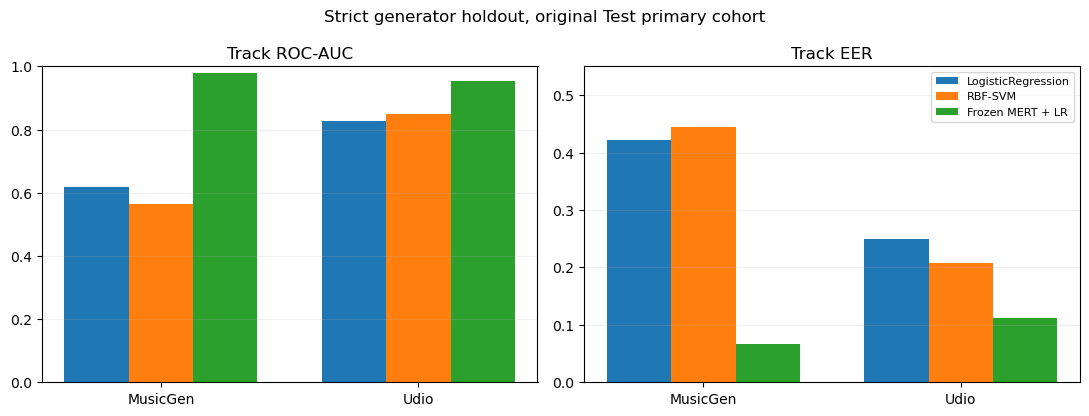

Saved: results/unseen_revised_classical_mert/unseen_classical_mert_20260919T171142Z/primary_track_auc_eer.png


In [6]:
# 보조 실험 세 모델의 Track AUC·EER을 대상별로 시각화한다.
track = primary.loc[primary.level.eq("track")].copy()
model_order = ["LogisticRegression", "RBF-SVM", "Frozen MERT + LR"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
x = np.arange(2)
width = 0.25
for i, model in enumerate(model_order):
    part = (
        track.loc[track.model.eq(model)]
        .set_index("holdout_generator")
        .loc[["musicgen", "udio"]]
    )
    axes[0].bar(x + (i - 1) * width, part["roc_auc"], width, label=model)
    axes[1].bar(x + (i - 1) * width, part["eer"], width, label=model)
for ax, metric, top in zip(axes, ["Track ROC-AUC", "Track EER"], [1.0, 0.55]):
    ax.set_xticks(x, ["MusicGen", "Udio"])
    ax.set_ylim(0, top)
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.2)
axes[1].legend(loc="upper right", fontsize=8)
fig.suptitle("Strict generator holdout, original Test primary cohort")
fig.tight_layout()
figure_path = RESULT / "primary_track_auc_eer.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", figure_path.relative_to(ROOT))

Track 그림에서 MusicGen MERT AUC 0.9798/EER 0.0667, Udio MERT 0.9551/0.1111이 보인다. 두 대상 모두 LR·SVM보다 MERT 막대의 AUC가 높고 EER이 낮다.

이 그림은 세 모델의 순위 성능 차이를 대상별 동일 Test ID에서 한눈에 보여준다.

그림은 분산·신뢰구간을 포함하지 않고, 외부 생성기나 데이터셋으로의 일반화를 입증하지 않는다.

## 5. Udio paired-source 보조 분석

Udio FAKE가 있는 원곡 24개만 남기면 REAL 24·FAKE 48 Track이다. 불균형이 남고 표본도 작아 primary 결과를 대체하지 않는다. MusicGen은 FAKE가 REAL 원곡 45개 모두에 있으므로 paired-source와 primary가 동일하다.

In [7]:
# Udio의 대응 원곡만 남긴 보조 cohort를 Primary와 분리해 표시한다.
print("Udio paired-source Test Track (REAL 24, FAKE 48):")
display(
    paired.loc[paired.holdout_generator.eq("udio") & paired.level.eq("track"), columns]
    .round(4)
    .reset_index(drop=True)
)

Udio paired-source Test Track (REAL 24, FAKE 48):


,holdout_generator,model,n_real,n_fake,roc_auc,ap_fake,ap_real,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,hter
0,udio,LogisticRegression,24,48,0.8125,0.8889,0.6778,0.2500,0.6979,0.6495,0.1667,0.4375,0.3021
1,udio,RBF-SVM,24,48,0.8377,0.9044,0.7501,0.2083,0.7188,0.6643,0.1250,0.4375,0.2812
2,udio,Frozen MERT + LR,24,48,0.9540,0.9760,0.9158,0.0833,0.8125,0.7601,0.0417,0.3333,0.1875


Udio paired-source Track의 REAL/FAKE는 24/48개이고 AUC/EER은 LR 0.8125/0.2500, SVM 0.8377/0.2083, MERT 0.9540/0.0833이다.

같은 원곡이 있는 REAL로 좁혀도 MERT의 높은 순위 분리력이 관측됐다.

REAL 수가 45개에서 24개로 바뀐 작은 불균형 코호트다. Primary와의 차이를 모델 개선이나 원곡 통제 효과로 단정하지 않는다.

## 6. 해석 범위와 재현

원본 Test 및 MusicGen/Udio 생성기는 **2026-09-13 과거 분석과 2026-09-20 공동 Test에서 이미 노출**되었다. 이번 필터된 Train/Validation 재탐색은 이전 선택 설정을 재사용하지 않았지만, 대상·탐색 공간·분석 결정을 완전히 미노출 상태에서 사전 등록한 평가는 아니다. MERT 외부 사전학습 자료의 중복 여부도 확인되지 않았다. 결과는 이 고정 데이터·코호트·시드에서의 후속 강건성 관측치다.

검증 스크립트는 저장된 raw score의 Test ID, Track 평균, 후보 선택, 여섯 체크포인트 해시와 모든 Primary/paired 분류 지표를 독립적으로 재계산한다. 원자료는 `primary_test_scores.csv`, `primary_test_metrics.csv`, `paired_source_test_metrics.csv`, `tuning.csv`, `selected_configs.json`, `run_metadata.json`에 저장되어 있다.

In [8]:
# 저장된 보조 실험 결과를 독립 검증기로 재계산한다.
import subprocess
import sys

check = subprocess.run(
    [sys.executable, "-m", "scripts.verify_unseen_classical_mert"],
    cwd=ROOT,
    text=True,
    capture_output=True,
    check=True,
)
print(check.stdout.strip())

PASS unseen_classical_mert_20260919T171142Z: 172 candidates, six checkpoints, 12 primary and 12 paired metric rows
protocol_sha256=95f1546ce8e3fcedb66e5ef52488c9255e414965514b5163e1a62b9052e4941e
tuning_sha256=2f00af550c79dc5c21e330fb482921ae480ecc2aa3bc6975485b923099591b43
selected_configs_sha256=9966764ed0cc4cf89804308ef7ffc3145325cbdca8cc7e03451e49287e617d16


읽기 전용 검증이 `PASS`였다. 후보 172개, 체크포인트 6개, primary 12행·paired-source 12행의 Segment·Track 지표가 저장 점수에서 재계산됐다.

이 run의 선택 기록, Test ID, Track 평균, 임계값과 지표가 내부적으로 일치한다.

재계산은 원래 Test의 과거 노출이나 MERT 사전학습 자료의 잠재적 중복을 제거하지 않는다.